# OTT Content Strategy & Trend Analysis

### Exploratory Data Analysis

**Tools:** Python | Pandas | Matplotlib | Seaborn | SQL | Power BI

**Objective:**  
Analyze OTT content trends, catalog composition, genres, ratings, geography,
and content characteristics to identify meaningful patterns and derive
actionable content strategy insights.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv("../data/raw/titles.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5806
Columns: 15


In [6]:
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0,27.612,8.2
2,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['comedy', 'fantasy']",['GB'],NaN,tt0071853,8.2,530877.0,18.216,7.8
3,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,392419.0,17.505,7.8
4,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,['horror'],['US'],NaN,tt0070047,8.1,391942.0,95.337,7.7


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Values,Missing %
seasons,3759,64.74
age_certification,2610,44.95
imdb_votes,539,9.28
imdb_score,523,9.01
imdb_id,444,7.65
tmdb_score,318,5.48
tmdb_popularity,94,1.62
description,18,0.31
title,1,0.02
id,0,0.00


In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


In [9]:
df["type"].value_counts()

type
MOVIE    3759
SHOW     2047
Name: count, dtype: int64

In [10]:
df[[
    "release_year",
    "runtime",
    "seasons",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,5806.0,2016.013434,7.324883,1945.000000,2015.00000,2018.000,2020.00000,2022.000
runtime,5806.0,77.643989,39.474160,0.000000,44.00000,84.000,105.00000,251.000
seasons,2047.0,2.165608,2.636207,1.000000,1.00000,1.000,2.00000,42.000
imdb_score,5283.0,6.533447,1.160932,1.500000,5.80000,6.600,7.40000,9.600
imdb_votes,5267.0,23407.194988,87134.315849,5.000000,521.00000,2279.000,10144.00000,2268288.000
tmdb_popularity,5712.0,22.525660,68.849177,0.009442,3.15525,7.478,17.77575,1823.374
tmdb_score,5488.0,6.818039,1.171560,0.500000,6.10000,6.900,7.50000,10.000


In [11]:
print("Runtime = 0:", (df["runtime"] == 0).sum())

Runtime = 0: 24


In [12]:
df[df["runtime"] == 0][
    ["id", "title", "type", "runtime"]
].head(20)

,id,title,type,runtime
472,ts74931,Kung Fu Panda Awesome Secrets,SHOW,0
478,ts98252,Dreamworks Happy Holidays from Madagascar,SHOW,0
561,ts67595,Pedro El Escamoso,SHOW,0
896,ts99814,Masameer,SHOW,0
2618,ts74765,Daughters of Destiny,SHOW,0
2627,ts94470,Relatable,SHOW,0
3130,ts104093,Dance & Sing With True,SHOW,0
3165,ts250172,Afronta!,SHOW,0
3752,ts268592,Beyblade Burst Rise,SHOW,0
3981,ts217719,Basketball or Nothing,SHOW,0


In [13]:
clean_df = df.copy()

# Convert invalid runtime values to missing
clean_df["runtime"] = clean_df["runtime"].replace(0, np.nan)

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Runtime values converted to missing:", clean_df["runtime"].isna().sum())

Original rows: 5806
Cleaned rows: 5806
Runtime values converted to missing: 24


In [14]:
clean_df["age_certification"] = clean_df["age_certification"].fillna("Not Rated")

print("Missing age certifications:",
      clean_df["age_certification"].isna().sum())

Missing age certifications: 0


In [15]:
clean_df[clean_df["title"].isna()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1805,tm1063792,NaN,MOVIE,NaN,2015,Not Rated,11.0,[],[],NaN,tt4661188,NaN,NaN,NaN,NaN


In [16]:
clean_df = clean_df.dropna(subset=["title"]).copy()

print("Rows after removing missing title:", len(clean_df))
print("Missing titles:", clean_df["title"].isna().sum())

Rows after removing missing title: 5805
Missing titles: 0


In [17]:
clean_df["genres_list"] = clean_df["genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

clean_df["countries_list"] = clean_df["production_countries"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

print("Genres and countries converted successfully.")

Genres and countries converted successfully.


In [18]:
clean_df["genres_clean"] = clean_df["genres_list"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) and len(x) > 0 else "Unknown"
)

clean_df["countries_clean"] = clean_df["countries_list"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) and len(x) > 0 else "Unknown"
)

print("Clean genre and country columns created.")

Clean genre and country columns created.


In [19]:
clean_df[["title", "genres", "genres_clean", "production_countries", "countries_clean"]].head()

,title,genres,genres_clean,production_countries,countries_clean
0,Five Came Back: The Reference Films,['documentation'],documentation,['US'],US
1,Taxi Driver,"['crime', 'drama']","crime, drama",['US'],US
2,Monty Python and the Holy Grail,"['comedy', 'fantasy']","comedy, fantasy",['GB'],GB
3,Life of Brian,['comedy'],comedy,['GB'],GB
4,The Exorcist,['horror'],horror,['US'],US


In [20]:
clean_df["release_decade"] = (clean_df["release_year"] // 10) * 10

clean_df["content_age"] = 2022 - clean_df["release_year"]

clean_df["is_high_rated"] = clean_df["imdb_score"] >= 7

print("Feature engineering completed.")

Feature engineering completed.


In [21]:
clean_df[
    ["title", "release_year", "release_decade", "content_age", "imdb_score", "is_high_rated"]
].head(10)

,title,release_year,release_decade,content_age,imdb_score,is_high_rated
0,Five Came Back: The Reference Films,1945,1940,77,NaN,False
1,Taxi Driver,1976,1970,46,8.3,True
2,Monty Python and the Holy Grail,1975,1970,47,8.2,True
3,Life of Brian,1979,1970,43,8.0,True
4,The Exorcist,1973,1970,49,8.1,True
5,Monty Python's Flying Circus,1969,1960,53,8.8,True
6,Dirty Harry,1971,1970,51,7.7,True
7,My Fair Lady,1964,1960,58,7.8,True
8,The Blue Lagoon,1980,1980,42,5.8,False
9,Bonnie and Clyde,1967,1960,55,7.7,True


In [23]:
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

print("\nDuplicate IDs:", clean_df["id"].duplicated().sum())

print("\nMissing values:")
print(clean_df.isnull().sum().sort_values(ascending=False))

Rows: 5805
Columns: 22

Duplicate IDs: 0

Missing values:
seasons                 3758
imdb_votes               538
imdb_score               522
imdb_id                  444
tmdb_score               317
tmdb_popularity           93
runtime                   24
description               17
age_certification          0
title                      0
id                         0
release_year               0
type                       0
production_countries       0
genres                     0
genres_list                0
countries_list             0
genres_clean               0
countries_clean            0
release_decade             0
content_age                0
is_high_rated              0
dtype: int64


In [24]:
clean_df.to_csv(
    "../data/cleaned/ott_titles_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [25]:
type_counts = clean_df["type"].value_counts()

print(type_counts)

type
MOVIE    3758
SHOW     2047
Name: count, dtype: int64


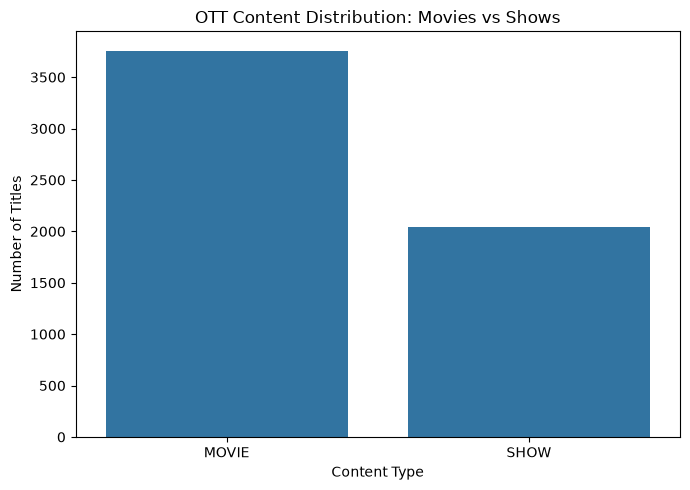

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="type",
    order=type_counts.index
)

plt.title("OTT Content Distribution: Movies vs Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [27]:
yearly_content = (
    clean_df.groupby(["release_year", "type"])
    .size()
    .reset_index(name="title_count")
)

yearly_content.head()

,release_year,type,title_count
0,1945,SHOW,1
1,1953,MOVIE,1
2,1954,MOVIE,2
3,1956,MOVIE,1
4,1958,MOVIE,1


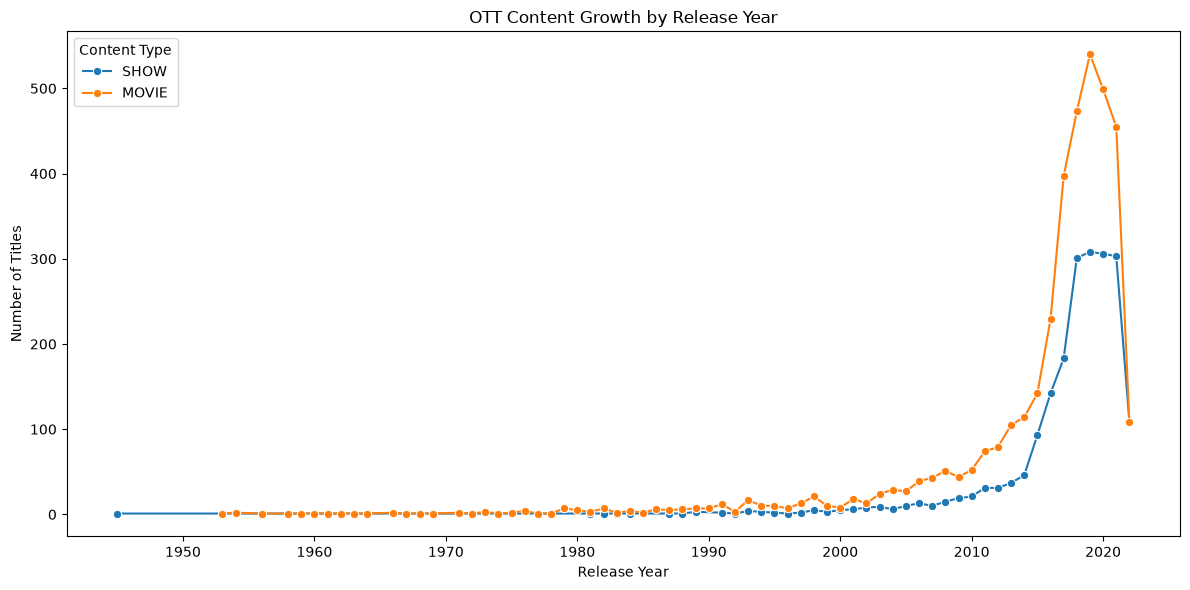

In [28]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_content,
    x="release_year",
    y="title_count",
    hue="type",
    marker="o"
)

plt.title("OTT Content Growth by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")

plt.tight_layout()
plt.show()

In [29]:
decade_counts = (
    clean_df["release_decade"]
    .value_counts()
    .sort_index()
)

print(decade_counts)

release_decade
1940       1
1950       6
1960      11
1970      23
1980      56
1990     133
2000     397
2010    3398
2020    1780
Name: count, dtype: int64


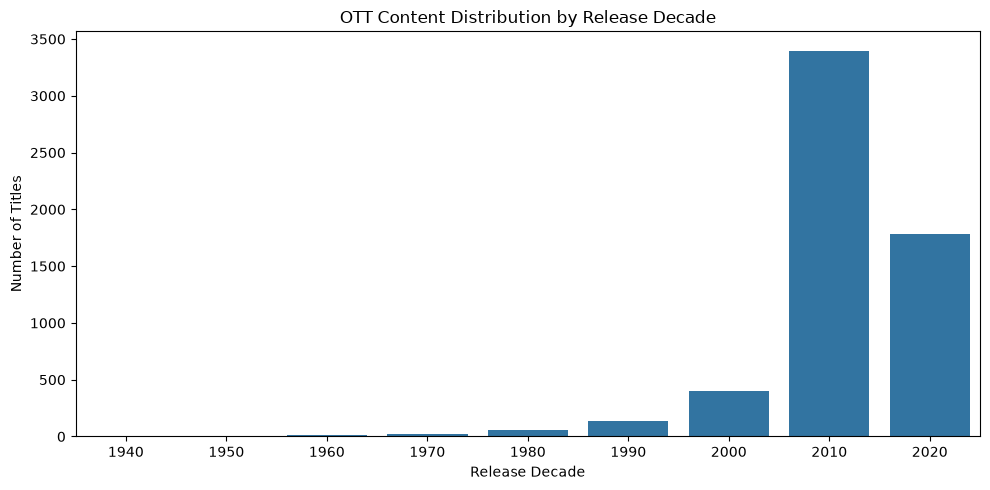

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=decade_counts.index,
    y=decade_counts.values
)

plt.title("OTT Content Distribution by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [31]:
rating_by_type = (
    clean_df.groupby("type")["imdb_score"]
    .mean()
    .sort_values(ascending=False)
)

print(rating_by_type.round(2))

type
SHOW     7.02
MOVIE    6.27
Name: imdb_score, dtype: float64


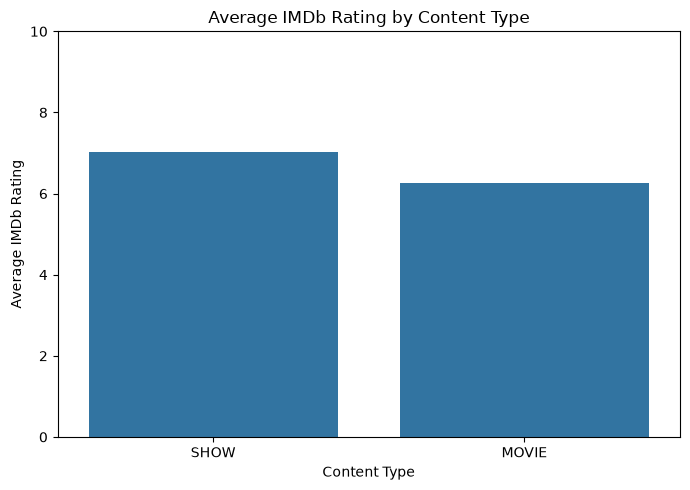

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=rating_by_type.index,
    y=rating_by_type.values
)

plt.title("Average IMDb Rating by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average IMDb Rating")

plt.ylim(0, 10)

plt.tight_layout()
plt.show()

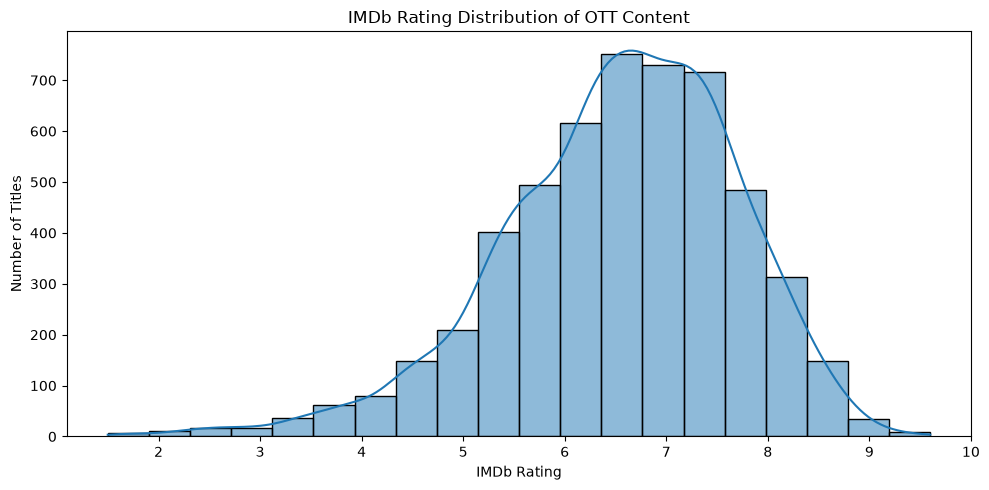

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=clean_df,
    x="imdb_score",
    bins=20,
    kde=True
)

plt.title("IMDb Rating Distribution of OTT Content")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [34]:
genre_data = clean_df.explode("genres_list")

genre_counts = (
    genre_data["genres_list"]
    .value_counts()
    .head(10)
)

print(genre_counts)

genres_list
drama            2901
comedy           2269
thriller         1178
action           1053
romance           958
documentation     910
crime             891
animation         665
fantasy           631
family            622
Name: count, dtype: int64


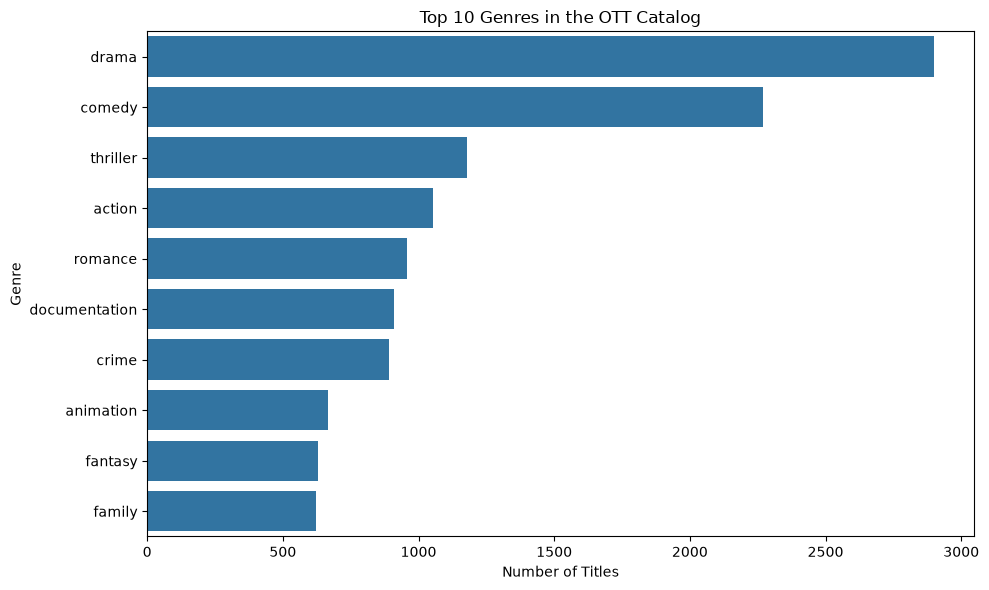

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres in the OTT Catalog")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [36]:
country_data = clean_df.explode("countries_list")

country_counts = (
    country_data["countries_list"]
    .value_counts()
    .head(10)
)

print(country_counts)


countries_list
US    2327
IN     629
GB     406
JP     291
FR     248
CA     216
KR     216
ES     212
DE     139
MX     123
Name: count, dtype: int64


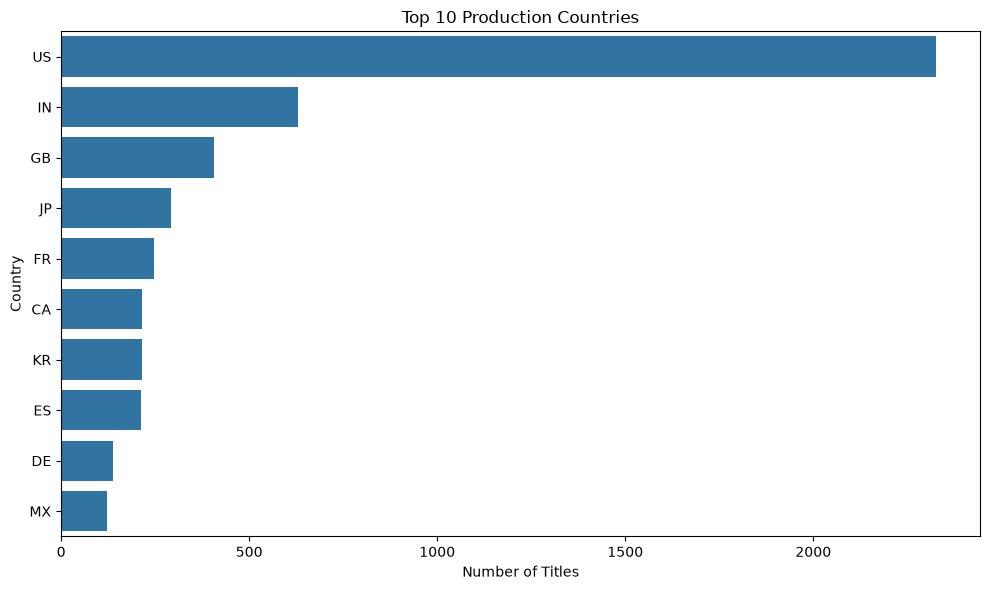

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Production Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [38]:

movie_runtime = clean_df[
    (clean_df["type"] == "MOVIE") &
    (clean_df["runtime"].notna())
]

print("Average Movie Runtime:", round(movie_runtime["runtime"].mean(), 2), "minutes")

Average Movie Runtime: 98.81 minutes


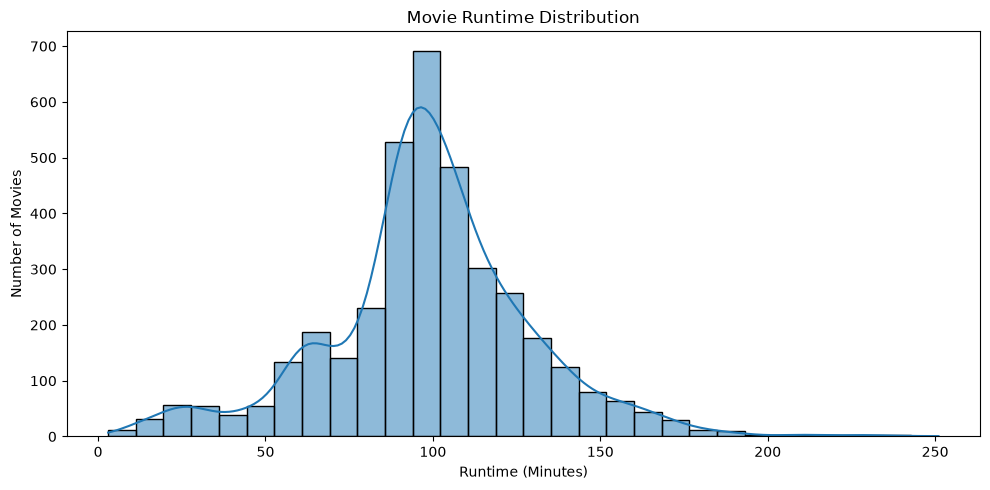

In [39]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=movie_runtime,
    x="runtime",
    bins=30,
    kde=True
)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

In [41]:
show_seasons = clean_df[
    (clean_df["type"] == "SHOW") &
    (clean_df["seasons"].notna())
]

print("Average Show Seasons:", round(show_seasons["seasons"].mean(), 2))

Average Show Seasons: 2.17


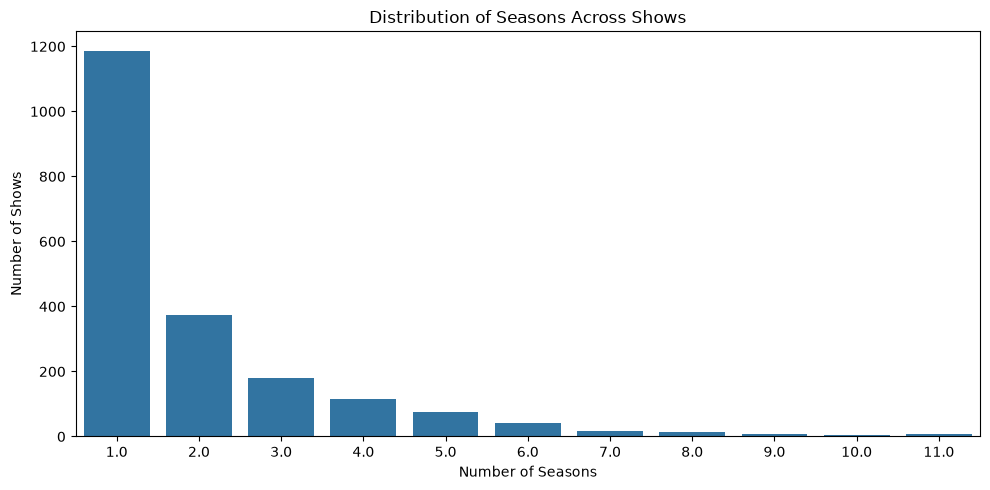

In [42]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=show_seasons,
    x="seasons"
)

plt.title("Distribution of Seasons Across Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")

plt.xlim(-0.5, 10.5)

plt.tight_layout()
plt.show()

In [43]:
rating_popularity = clean_df[
    ["title", "type", "imdb_score", "tmdb_popularity"]
].dropna()

print("Records available:", len(rating_popularity))

Records available: 5199


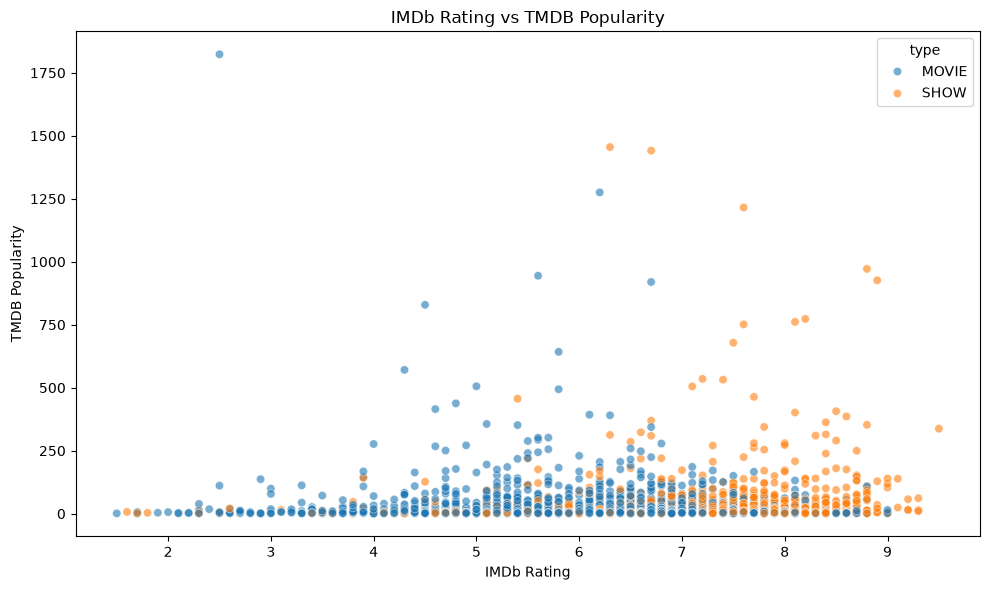

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rating_popularity,
    x="imdb_score",
    y="tmdb_popularity",
    hue="type",
    alpha=0.6
)

plt.title("IMDb Rating vs TMDB Popularity")
plt.xlabel("IMDb Rating")
plt.ylabel("TMDB Popularity")

plt.tight_layout()
plt.show()

In [45]:
content_summary = clean_df.groupby("type").agg(
    titles=("title", "count"),
    avg_imdb_score=("imdb_score", "mean"),
    avg_runtime=("runtime", "mean")
).round(2)

content_summary

,titles,avg_imdb_score,avg_runtime
type,,,
MOVIE,3758,6.27,98.81
SHOW,2047,7.02,39.28


In [46]:
genre_summary = (
    genre_data.groupby("genres_list")
    .agg(
        titles=("title", "count"),
        avg_imdb_score=("imdb_score", "mean")
    )
    .sort_values("titles", ascending=False)
    .head(10)
    .round(2)
)

genre_summary

,titles,avg_imdb_score
genres_list,,
drama,2901,6.66
comedy,2269,6.42
thriller,1178,6.36
action,1053,6.46
romance,958,6.44
documentation,910,7.04
crime,891,6.68
animation,665,6.73
fantasy,631,6.58


In [47]:
country_summary = (
    country_data.groupby("countries_list")
    .agg(
        titles=("title", "count"),
        avg_imdb_score=("imdb_score", "mean")
    )
    .sort_values("titles", ascending=False)
    .head(10)
    .round(2)
)

country_summary

,titles,avg_imdb_score
countries_list,,
US,2327,6.55
IN,629,6.39
GB,406,6.79
JP,291,7.00
FR,248,6.44
KR,216,7.22
CA,216,6.32
ES,212,6.40
DE,139,6.43


In [48]:
high_rated_summary = (
    clean_df.groupby("type")["is_high_rated"]
    .agg(["sum", "count"])
)

high_rated_summary["percentage"] = (
    high_rated_summary["sum"] /
    high_rated_summary["count"] * 100
).round(2)

high_rated_summary

,sum,count,percentage
type,,,
MOVIE,980,3758,26.08
SHOW,1084,2047,52.96


In [49]:
top_rated_genres = (
    genre_data.groupby("genres_list")
    .agg(
        titles=("title", "count"),
        avg_imdb_score=("imdb_score", "mean")
    )
    .query("titles >= 20")
    .sort_values("avg_imdb_score", ascending=False)
    .head(10)
    .round(2)
)

top_rated_genres

,titles,avg_imdb_score
genres_list,,
history,233,7.15
war,149,7.09
documentation,910,7.04
animation,665,6.73
sport,166,6.71
crime,891,6.68
drama,2901,6.66
music,238,6.63
western,44,6.60


In [50]:
eda_summary = {
    "Total Titles": len(clean_df),
    "Movies": (clean_df["type"] == "MOVIE").sum(),
    "Shows": (clean_df["type"] == "SHOW").sum(),
    "Average IMDb Rating": round(clean_df["imdb_score"].mean(), 2),
    "Average Movie Runtime": round(
        clean_df.loc[clean_df["type"] == "MOVIE", "runtime"].mean(), 2
    ),
    "Average Show Seasons": round(
        clean_df.loc[clean_df["type"] == "SHOW", "seasons"].mean(), 2
    ),
    "High-Rated Titles (IMDb >= 7)": clean_df["is_high_rated"].sum()
}

eda_summary

{'Total Titles': 5805,
 'Movies': np.int64(3758),
 'Shows': np.int64(2047),
 'Average IMDb Rating': np.float64(6.53),
 'Average Movie Runtime': np.float64(98.81),
 'Average Show Seasons': np.float64(2.17),
 'High-Rated Titles (IMDb >= 7)': np.int64(2064)}

## EDA Summary

The exploratory analysis examined the OTT catalog across content type, release trends,
ratings, genres, production countries, duration, and popularity. These findings will
be used to identify content patterns and develop data-driven content strategy insights.

In [51]:
sql_df = clean_df.copy()

# Keep the main columns needed for SQL analysis
sql_df = sql_df[
    [
        "id",
        "title",
        "type",
        "release_year",
        "release_decade",
        "age_certification",
        "runtime",
        "genres_clean",
        "countries_clean",
        "seasons",
        "imdb_score",
        "imdb_votes",
        "tmdb_popularity",
        "tmdb_score"
    ]
]

sql_df.to_csv(
    "../data/cleaned/ott_sql_data.csv",
    index=False
)

print("SQL dataset created successfully.")
print("Rows:", len(sql_df))
print("Columns:", len(sql_df.columns))

SQL dataset created successfully.
Rows: 5805
Columns: 14


In [52]:
print(sql_df.shape)

(5805, 14)


In [53]:
sql_df.head()

,id,title,type,release_year,release_decade,age_certification,runtime,genres_clean,countries_clean,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,1940,TV-MA,48.0,documentation,US,1.0,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,1976,1970,R,113.0,"crime, drama",US,NaN,8.3,795222.0,27.612,8.2
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,1970,PG,91.0,"comedy, fantasy",GB,NaN,8.2,530877.0,18.216,7.8
3,tm70993,Life of Brian,MOVIE,1979,1970,R,94.0,comedy,GB,NaN,8.0,392419.0,17.505,7.8
4,tm190788,The Exorcist,MOVIE,1973,1970,R,133.0,horror,US,NaN,8.1,391942.0,95.337,7.7


In [54]:
import pandas as pd

check_csv = pd.read_csv("../data/cleaned/ott_sql_data.csv")

print("CSV rows:", check_csv.shape[0])
print("CSV columns:", check_csv.shape[1])

CSV rows: 5805
CSV columns: 14


In [55]:
check_csv.tail()

,id,title,type,release_year,release_decade,age_certification,runtime,genres_clean,countries_clean,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
5800,tm1014599,Fine Wine,MOVIE,2021,2020,Not Rated,100.0,"romance, drama",NG,NaN,6.9,39.0,0.966,NaN
5801,tm1108171,Edis Starlight,MOVIE,2021,2020,Not Rated,74.0,"music, documentation",Unknown,NaN,NaN,NaN,1.036,8.5
5802,tm1045018,Clash,MOVIE,2021,2020,Not Rated,88.0,"family, drama","NG, CA",NaN,6.5,32.0,0.709,NaN
5803,tm1098060,Shadow Parties,MOVIE,2021,2020,Not Rated,116.0,"action, thriller",Unknown,NaN,6.2,9.0,2.186,NaN
5804,ts271048,Mighty Little Bheem: Kite Festival,SHOW,2021,2020,Not Rated,NaN,"family, comedy, animation",Unknown,1.0,8.8,16.0,0.979,10.0
